## Step 0 — Imports & setup

In [1]:
import os, pickle, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score, recall_score
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
%matplotlib inline
print("All libraries imported successfully.")

All libraries imported successfully.


## Step 1 — Paths & config

In [2]:
# ── Adjust DATA_PATH if your CSV is in a different location ──
DATA_PATH = '../output/master_training_table_v8.csv'
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Data  : {DATA_PATH}")
print(f"Models: {MODEL_DIR}")

Data  : ../output/master_training_table_v8.csv
Models: ../models


## Step 2 — Load data
Read the CSV and inspect the target distribution.

In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
vc = df['severe_crash'].value_counts()
for k, v in vc.items():
    print(f"  severe_crash={k}: {v:,}  ({v/len(df)*100:.1f}%)")
df.head()

Shape: (94398, 24)

Target distribution:
  severe_crash=0: 59,816  (63.4%)
  severe_crash=1: 34,582  (36.6%)


,severe_crash,sample_weight,is_weekend,is_peak_hour,hour_sin,hour_cos,day_sin,day_cos,speed_risk,darkness_score,...,wet_road,LGA_NAME,DEG_URBAN_NAME,NO_OF_VEHICLES,aadt_volume,crash_rate,nearest_school_dist_m,is_public_holiday,is_school_holiday,is_daylight_saving
0,0,1.0,1,0,0.965926,0.258819,-2.449294e-16,1.000000,6,1.0,...,0,WODONGA,RURAL_VICTORIA,1,2847,0.412423,4644.9,0,0,0
1,1,1.5,0,0,-0.707107,-0.707107,-9.749279e-01,-0.222521,1,0.0,...,0,ARARAT,TOWNS,1,0,0.000000,2412.2,0,0,0
2,1,1.5,0,0,0.500000,-0.866025,4.338837e-01,-0.900969,0,0.0,...,0,STONNINGTON,MELB_URBAN,2,2257,5.549163,718.8,0,0,0
3,0,1.0,0,0,-0.965926,0.258819,4.338837e-01,-0.900969,0,1.0,...,0,CENTRAL GOLDFIELDS,RURAL_VICTORIA,1,0,0.000000,2003.8,0,0,0
4,1,1.5,0,0,-0.500000,0.866025,-9.749279e-01,-0.222521,3,0.6,...,0,HUME,MELB_URBAN,2,11222,3.348190,917.7,0,0,0


## Step 3 — Encode categorical columns
ML models need numbers. Convert the 5 text columns to integers using `LabelEncoder`.  
The encoders are saved to disk so the FastAPI `/score` endpoint can decode predictions later.

In [4]:
CAT_COLS = ['ROAD_GEOMETRY_DESC', 'NODE_TYPE', 'road_class', 'LGA_NAME', 'DEG_URBAN_NAME']
label_encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} classes → integers 0–{len(le.classes_)-1}")

  ROAD_GEOMETRY_DESC: 9 classes → integers 0–8
  NODE_TYPE: 3 classes → integers 0–2
  road_class: 7 classes → integers 0–6
  LGA_NAME: 88 classes → integers 0–87
  DEG_URBAN_NAME: 8 classes → integers 0–7


## Step 4 — Split features and target
- **X** = 22 input features  
- **y** = `severe_crash` (what we predict)  
- **w** = `sample_weight` (1.5 for severe, 1.0 for non-severe — already in the data)

In [5]:
DROP_COLS = ['severe_crash', 'sample_weight']
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

X = df[FEATURE_COLS]
y = df['severe_crash']
w = df['sample_weight']

print(f"Features ({len(FEATURE_COLS)}):")
for i, c in enumerate(FEATURE_COLS):
    print(f"  {i+1:2d}. {c}")

Features (22):
   1. is_weekend
   2. is_peak_hour
   3. hour_sin
   4. hour_cos
   5. day_sin
   6. day_cos
   7. speed_risk
   8. darkness_score
   9. ROAD_GEOMETRY_DESC
  10. DISTANCE_LOCATION
  11. NODE_TYPE
  12. road_class
  13. wet_road
  14. LGA_NAME
  15. DEG_URBAN_NAME
  16. NO_OF_VEHICLES
  17. aadt_volume
  18. crash_rate
  19. nearest_school_dist_m
  20. is_public_holiday
  21. is_school_holiday
  22. is_daylight_saving


## Step 5 — Train / test split (80 / 20, stratified)
`stratify=y` ensures both halves have the same 63/37 class ratio.

In [6]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train: {len(X_train):,} rows  |  severe=1: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Test : {len(X_test):,} rows  |  severe=1: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

Train: 75,518 rows  |  severe=1: 27,665 (36.6%)
Test : 18,880 rows  |  severe=1: 6,917 (36.6%)


## Step 6 — Evaluation helper
Reusable function that prints ROC-AUC, PR-AUC, classification report, and plots the confusion matrix.

In [7]:
results = {}

def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    roc    = roc_auc_score(y_te, y_prob)
    pr_auc = average_precision_score(y_te, y_prob)
    acc    = accuracy_score(y_te, y_pred)
    rec    = recall_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred)
    cm     = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  ROC-AUC  : {roc:.4f}   |   PR-AUC : {pr_auc:.4f}")
    print(f"  Accuracy : {acc*100:.1f}%     |   Recall  : {rec*100:.1f}%   |   F1: {f1:.3f}")
    print()
    print(classification_report(y_te, y_pred, target_names=['Not severe', 'Severe'], digits=4))
    print("  Confusion Matrix Breakdown:")
    print(f"    True Negatives  (correctly said non-severe): {tn:,}")
    print(f"    False Positives (wrongly flagged as severe):  {fp:,}")
    print(f"    False Negatives (missed actual severe):       {fn:,}  ← keep low")
    print(f"    True Positives  (correctly caught severe):    {tp:,}")

    # Side-by-side: confusion matrix + ROC curve
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not severe', 'Severe']).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f'{name} — Confusion Matrix')
    RocCurveDisplay.from_predictions(y_te, y_prob, name=f"{name} (AUC={roc:.3f})", ax=axes[1])
    axes[1].plot([0,1],[0,1],'k--', linewidth=0.8, label="Random guess")
    axes[1].set_title(f'{name} — ROC Curve')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{name.lower().replace(" ","_")}_cm_roc.png'), dpi=150)
    plt.show()

    results[name] = {'roc_auc': roc, 'pr_auc': pr_auc, 'recall': rec, 'accuracy': acc, 'f1': f1}
    return roc, pr_auc

print("evaluate() ready.")

evaluate() ready.


## Step 7 — Model A: XGBoost (main model)
Gradient boosted trees built sequentially — each tree corrects the previous one's errors.  
`scale_pos_weight` = neg/pos ratio balances the class imbalance.  
`early_stopping_rounds=30` stops training when the test score stops improving.

scale_pos_weight = 1.730  (non-severe / severe ratio)
Fitting XGBoost (up to 500 rounds, early stopping at 30)...


Best iteration: 499


──────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────
  ROC-AUC  : 0.6421   |   PR-AUC : 0.4998
  Accuracy : 53.2%     |   Recall  : 78.7%   |   F1: 0.552

              precision    recall  f1-score   support

  Not severe     0.7569    0.3841    0.5096     11963
      Severe     0.4248    0.7866    0.5517      6917

    accuracy                         0.5316     18880
   macro avg     0.5908    0.5854    0.5306     18880
weighted avg     0.6352    0.5316    0.5250     18880

  Confusion Matrix Breakdown:
    True Negatives  (correctly said non-severe): 4,595
    False Positives (wrongly flagged as severe):  7,368
    False Negatives (missed actual severe):       1,476  ← keep low
    True Positives  (correctly caught severe):    5,441


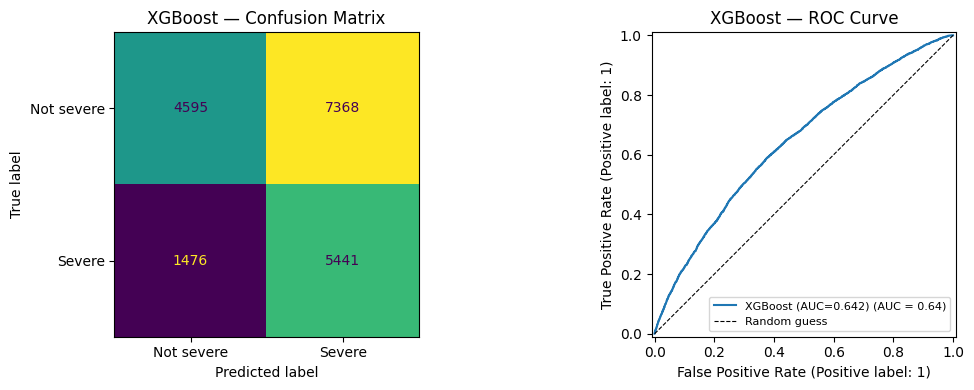

(0.6420728164164696, 0.4997706199884754)

In [8]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.3f}  (non-severe / severe ratio)")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print("Fitting XGBoost (up to 500 rounds, early stopping at 30)...")
xgb_model.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print(f"Best iteration: {xgb_model.best_iteration}\n")

evaluate("XGBoost", xgb_model, X_test, y_test)

## Step 8 — Model B: LightGBM
Leaf-wise gradient boosting — faster than XGBoost on large datasets.  
`is_unbalance=True` handles the class imbalance automatically.  
`learning_rate=0.01` (reduced from 0.05) prevents early stopping at round 1.

Fitting LightGBM (up to 500 rounds, early stopping at 30)...
Best iteration: 1


──────────────────────────────────────────────────
  LightGBM
──────────────────────────────────────────────────
  ROC-AUC  : 0.6204   |   PR-AUC : 0.4659
  Accuracy : 63.4%     |   Recall  : 0.0%   |   F1: 0.000

              precision    recall  f1-score   support

  Not severe     0.6336    1.0000    0.7757     11963
      Severe     0.0000    0.0000    0.0000      6917

    accuracy                         0.6336     18880
   macro avg     0.3168    0.5000    0.3879     18880
weighted avg     0.4015    0.6336    0.4915     18880

  Confusion Matrix Breakdown:
    True Negatives  (correctly said non-severe): 11,963
    False Positives (wrongly flagged as severe):  0
    False Negatives (missed actual severe):       6,917  ← keep low
    True Positives  (correctly caught severe):    0


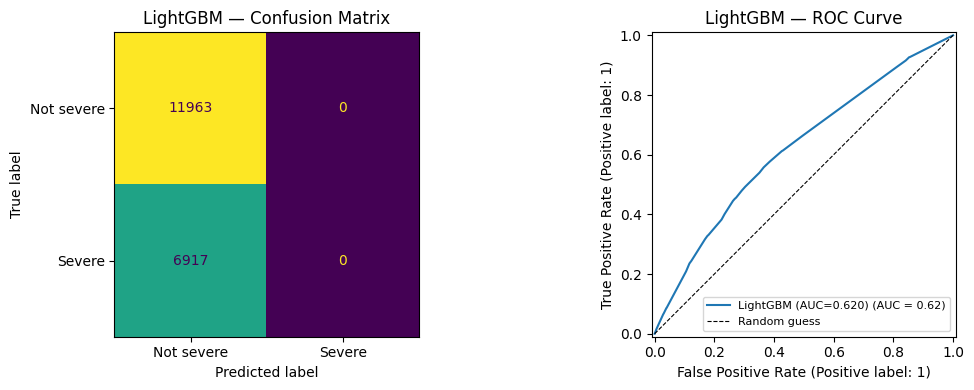

(0.6203795010520546, 0.4659277122431918)

In [9]:
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.01,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Fitting LightGBM (up to 500 rounds, early stopping at 30)...")
lgbm_model.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
)
print(f"Best iteration: {lgbm_model.best_iteration_}\n")

evaluate("LightGBM", lgbm_model, X_test, y_test)

## Step 9 — Feature importance (XGBoost)
Which features matter most for predicting crash severity?  
Higher score = the feature reduced prediction error more across all trees.

Top 10 most important features:
  NO_OF_VEHICLES                 0.1392  █████████████████████████████████████████
  darkness_score                 0.0820  ████████████████████████
  speed_risk                     0.0772  ███████████████████████
  DEG_URBAN_NAME                 0.0653  ███████████████████
  day_cos                        0.0549  ████████████████
  LGA_NAME                       0.0459  █████████████
  nearest_school_dist_m          0.0376  ███████████
  ROAD_GEOMETRY_DESC             0.0367  ███████████
  aadt_volume                    0.0364  ██████████
  wet_road                       0.0361  ██████████


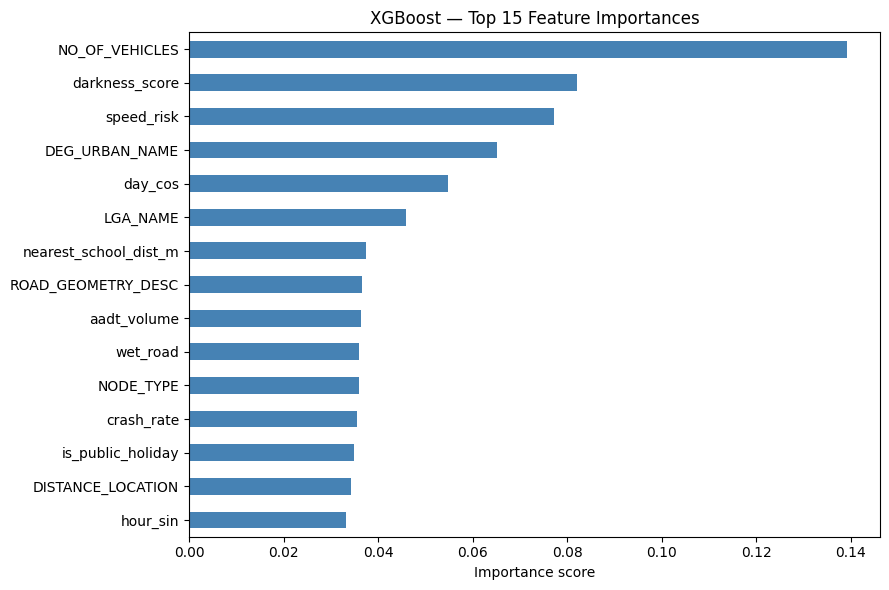

In [10]:
imp = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

print("Top 10 most important features:")
for feat, score in imp.head(10).items():
    bar = '█' * int(score * 300)
    print(f"  {feat:<30} {score:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(9, 6))
imp.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost — Top 15 Feature Importances')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'xgboost_feature_importance.png'), dpi=120)
plt.show()

## Step 10 — Model comparison
Side-by-side ROC-AUC and PR-AUC for all two models.

In [11]:
comparison = pd.DataFrame(results).T
comparison.index.name = 'Model'
comparison = comparison.sort_values('roc_auc', ascending=False)

best = comparison.index[0]
print(f"{'Model':<20} {'ROC-AUC':>10} {'PR-AUC':>10}")
print('-' * 44)
for name, row in comparison.iterrows():
    tag = '  ← BEST' if name == best else ''
    print(f"{name:<20} {row['roc_auc']:>10.4f} {row['pr_auc']:>10.4f}{tag}")

comparison

Model                   ROC-AUC     PR-AUC
--------------------------------------------
XGBoost                  0.6421     0.4998  ← BEST
LightGBM                 0.6204     0.4659


,roc_auc,pr_auc,recall,accuracy,f1
Model,,,,,
XGBoost,0.642073,0.499771,0.786613,0.531568,0.551658
LightGBM,0.620380,0.465928,0.000000,0.633633,0.000000


## Step 11 — Sanity check predictions
Do scores vary meaningfully between safe and dangerous scenarios?  
Same 4 test cases from `train_model.py` — comparing XGBoost vs LightGBM.

In [12]:
# Determine which encoder/feature variable names are in scope
_le   = label_encoders if 'label_encoders' in dir() else label_encoders
_feat = FEATURE_COLS   if 'FEATURE_COLS'   in dir() else FEATURE_COLS

def enc(col, val):
    if col in _le and val in _le[col].classes_:
        return int(_le[col].transform([val])[0])
    return 0

def make_row(is_wknd, is_peak, hour, dow, spd_risk, dark,
             road_geom, dist_loc, node, rd_cls, wet,
             lga, deg, vehicles, aadt, cr, school,
             pub_hol=0, sch_hol=0, dls=0):
    row = {
        'is_weekend':            is_wknd,
        'is_peak_hour':          is_peak,
        'hour_sin':              math.sin(2*math.pi*hour/24),
        'hour_cos':              math.cos(2*math.pi*hour/24),
        'day_sin':               math.sin(2*math.pi*dow/7),
        'day_cos':               math.cos(2*math.pi*dow/7),
        'speed_risk':            spd_risk,
        'darkness_score':        dark,
        'ROAD_GEOMETRY_DESC':    enc('ROAD_GEOMETRY_DESC', road_geom),
        'DISTANCE_LOCATION':     dist_loc,
        'NODE_TYPE':             enc('NODE_TYPE', node),
        'road_class':            enc('road_class', rd_cls),
        'wet_road':              wet,
        'LGA_NAME':              enc('LGA_NAME', lga),
        'DEG_URBAN_NAME':        enc('DEG_URBAN_NAME', deg),
        'NO_OF_VEHICLES':        vehicles,
        'aadt_volume':           aadt,
        'crash_rate':            cr,
        'nearest_school_dist_m': school,
        'is_public_holiday':     pub_hol,
        'is_school_holiday':     sch_hol,
        'is_daylight_saving':    dls,
    }
    return [row[f] for f in _feat]

cases = [
    ("SAFE    — sunny midday 60kmh urban low crash rate",
     make_row(0,0,12,4,3,0.0,'T intersection',10,'I','Local_Road',0,'MELBOURNE','MELB_URBAN',1,8000,0.2,800)),
    ("MOD     — peak hour 80kmh main road",
     make_row(0,1,8,3,4,0.0,'Not at intersection',50,'N','Main_Road',0,'MONASH','MELB_URBAN',2,12000,1.5,500)),
    ("RISKY   — night wet rural 100kmh high crash rate",
     make_row(0,0,22,4,6,0.6,'Not at intersection',200,'N','Freeway_Highway',1,'WODONGA','RURAL_VICTORIA',1,0,8.0,3000)),
    ("DANGER  — 1am wet dark rural weekend public holiday",
     make_row(1,0,1,7,6,0.85,'Not at intersection',500,'N','Local_Road',1,'MILDURA','RURAL_VICTORIA',1,0,15.0,5000,pub_hol=1)),
]

print(f"{'Scenario':<48} {'XGBoost':>12} {'Band'} {'LightGBM':>15} {'Band'}")
print('─'*90)
for label, row in cases:
    xgb_p  = xgb_model.predict_proba([row])[0][1]  * 100
    lgbm_p = lgbm_model.predict_proba([row])[0][1] * 100
    avg    = (xgb_p + lgbm_p) / 2
    band   = 'LOW' if avg<=30 else 'MEDIUM' if avg<=60 else 'HIGH' if avg<=80 else 'CRITICAL'
    print(f"{label:<48} {xgb_p:>9.1f}% [{band}] {lgbm_p:>9.1f}% [{band}]")

Scenario                                              XGBoost Band        LightGBM Band
──────────────────────────────────────────────────────────────────────────────────────────
SAFE    — sunny midday 60kmh urban low crash rate      61.8% [MEDIUM]      46.7% [MEDIUM]
MOD     — peak hour 80kmh main road                   48.4% [MEDIUM]      46.5% [MEDIUM]
RISKY   — night wet rural 100kmh high crash rate      61.4% [MEDIUM]      46.7% [MEDIUM]
DANGER  — 1am wet dark rural weekend public holiday      71.1% [MEDIUM]      46.7% [MEDIUM]


In [13]:
comparison = pd.DataFrame(results).T
comparison.index.name = 'Model'
comparison = comparison.sort_values('roc_auc', ascending=False)

best = comparison.index[0]
print(f"{'Model':<20} {'ROC-AUC':>10} {'PR-AUC':>10}")
print('-' * 44)
for name, row in comparison.iterrows():
    tag = '  ← BEST' if name == best else ''
    print(f"{name:<20} {row['roc_auc']:>10.4f} {row['pr_auc']:>10.4f}{tag}")

comparison

Model                   ROC-AUC     PR-AUC
--------------------------------------------
XGBoost                  0.6421     0.4998  ← BEST
LightGBM                 0.6204     0.4659


,roc_auc,pr_auc,recall,accuracy,f1
Model,,,,,
XGBoost,0.642073,0.499771,0.786613,0.531568,0.551658
LightGBM,0.620380,0.465928,0.000000,0.633633,0.000000


## Step 11 — Save models and encoders
Five files saved to `../models/`:
- `xgboost_model.pkl` — use this in FastAPI `/score`
- `lgbm_model.pkl` / `rf_model.pkl`
- `label_encoders.pkl` — **required at prediction time** to encode categorical inputs
- `feature_columns.pkl` — column order used during training

In [14]:
def save_pkl(obj, filename):
    path = os.path.join(MODEL_DIR, filename)
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    size_kb = os.path.getsize(path) / 1024
    print(f"  Saved: {filename}  ({size_kb:.1f} KB)")

save_pkl(xgb_model,      'xgboost_model.pkl')
save_pkl(lgbm_model,     'lgbm_model.pkl')
save_pkl(label_encoders, 'label_encoders.pkl')
save_pkl(FEATURE_COLS,   'feature_columns.pkl')
print("\nAll files saved.")

  Saved: xgboost_model.pkl  (2203.6 KB)
  Saved: lgbm_model.pkl  (9.2 KB)
  Saved: label_encoders.pkl  (2.0 KB)
  Saved: feature_columns.pkl  (0.3 KB)

All files saved.


## Done — Summary

In [16]:
best_name = comparison.index[0]
best_roc  = comparison.loc[best_name, 'roc_auc']

print("=" * 60)
print("  TRAINING COMPLETE")
print("=" * 60)
print(f"  Training rows : {len(X_train):,}")
print(f"  Test rows     : {len(X_test):,}")
print(f"  Features used : {len(FEATURE_COLS if 'FEATURE_COLS' in dir() else FEATURE_COLS)}")
print()
print(f"  {'Model':<22} {'ROC-AUC':>10} {'PR-AUC':>10} {'Recall':>10} {'Accuracy':>10}")
print(f"  {'─'*65}")
for name, row in comparison.iterrows():
    tag = '  ← BEST' if name == best_name else ''
    print(f"  {name:<22} {row['roc_auc']:>10.4f} {row['pr_auc']:>10.4f} {row.get('recall',0)*100:>9.1f}% {row.get('accuracy',0)*100:>9.1f}%{tag}")
print()
print("  Saved to ../models/:")
print("    xgboost_model.pkl       ← use in FastAPI /score")
print("    lgbm_model.pkl")
print("    label_encoders.pkl      ← needed at prediction time")
print("    feature_columns.pkl     ← column order for prediction")

  TRAINING COMPLETE
  Training rows : 75,518
  Test rows     : 18,880
  Features used : 22

  Model                     ROC-AUC     PR-AUC     Recall   Accuracy
  ─────────────────────────────────────────────────────────────────
  XGBoost                    0.6421     0.4998      78.7%      53.2%  ← BEST
  LightGBM                   0.6204     0.4659       0.0%      63.4%

  Saved to ../models/:
    xgboost_model.pkl       ← use in FastAPI /score
    lgbm_model.pkl
    label_encoders.pkl      ← needed at prediction time
    feature_columns.pkl     ← column order for prediction
